# Simulation study

In [1]:
import os 
import numpy as np
from joblib import Parallel,delayed
import matplotlib.pyplot as plt
from package import *
rc('text', usetex=True)
rc('font', family='serif')
sz = 32
n = 100
save_path = os.getcwd() + '\\' + 'image' + '\\' + 'simulation'+ '\\'
save_data_path = os.getcwd() + '\\' + 'data' + '\\' + 'synthesis'+ '\\'

### Convergence rate of paramaters

In simulation part, we will set repeat_time = 300.

In [23]:
repeat_time = 1 ### set 300
n = [200,400,600,800,1000]
v = [1,-0.5,0]

##### NURHM

In [24]:

N = lambda n: int(0.1*n*(np.log(n))**3)
m_lower = 2
m_upper = 8
simulation(n, N, v, m_lower, m_upper, repeat_time = repeat_time,name = 'NURHM')

----------
complete get edges: Num_Edges=2974, Num_Nodes = 200,m_lower = 2,m_upper = 8
[[144, 186, 49, 31, 122, 7, 56], [71, 58, 104], [183, 117, 173, 42, 160, 166], [160, 120, 109, 34, 89, 28, 31], [117, 186, 159, 34, 190, 17, 132], [96, 77], [113, 79, 85], [181, 95, 94, 50, 98, 26], [30, 102, 144, 111, 91, 183, 138], [69, 40, 92, 107, 137], [70, 46, 160, 21, 133, 39, 152], [199, 52], [165, 24, 31, 30], [90, 30, 42, 85], [48, 145, 193], [28, 141, 61], [129, 45, 38, 179, 62], [6, 87, 9], [146, 29], [117, 56], [199, 21, 140, 183, 189, 99], [142, 90, 167, 125, 99], [177, 94, 133, 149, 91], [154, 27, 121, 7, 100, 30], [169, 81, 109, 33, 36, 157], [58, 12, 48, 56, 67, 194], [143, 148, 72], [23, 124, 98, 106, 16, 25, 53], [77, 13], [159, 139, 123, 151, 82, 111, 119], [13, 90, 164, 34, 24], [48, 125, 172, 64, 68, 114], [26, 13, 98], [8, 167, 173, 153, 139, 34], [197, 20, 91, 172, 14, 101, 90], [179, 43, 22, 132, 193, 12, 166], [45, 47, 116, 160, 72, 77], [27, 116, 134, 113, 2, 176, 61], [99,

KeyboardInterrupt: 

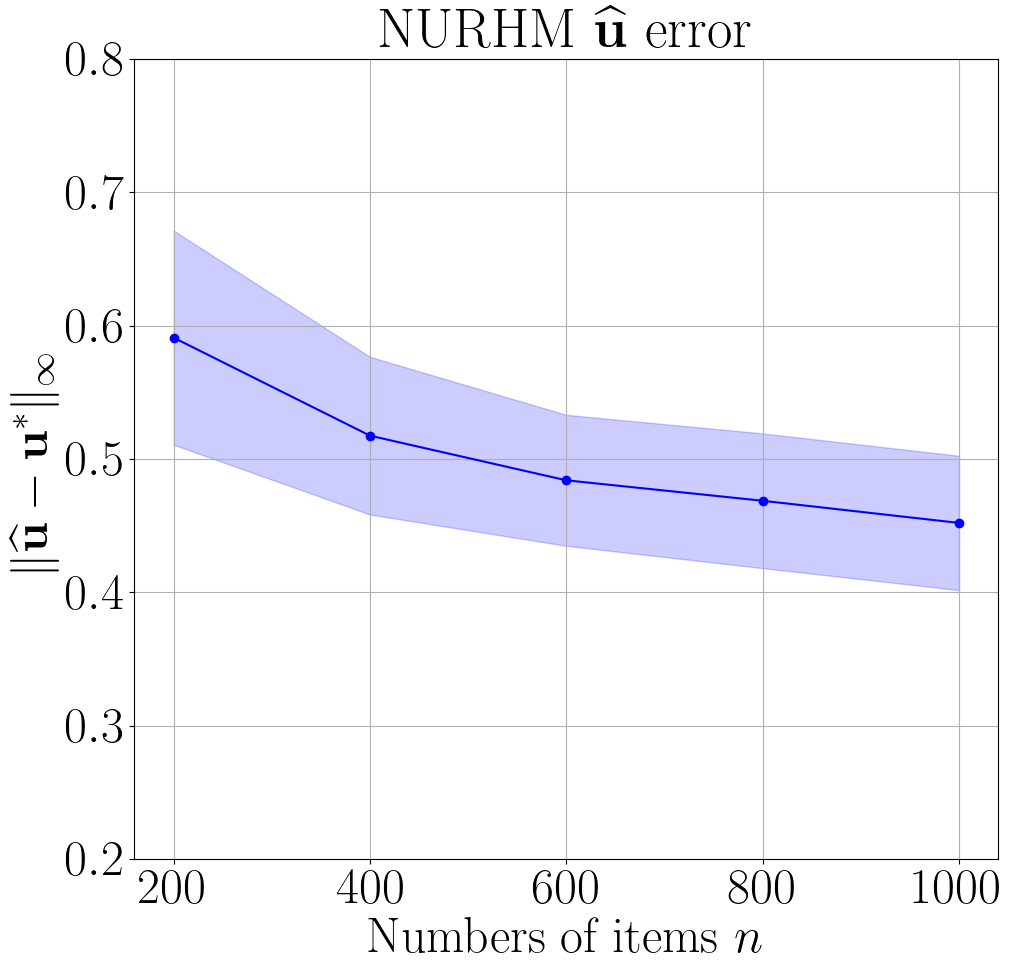

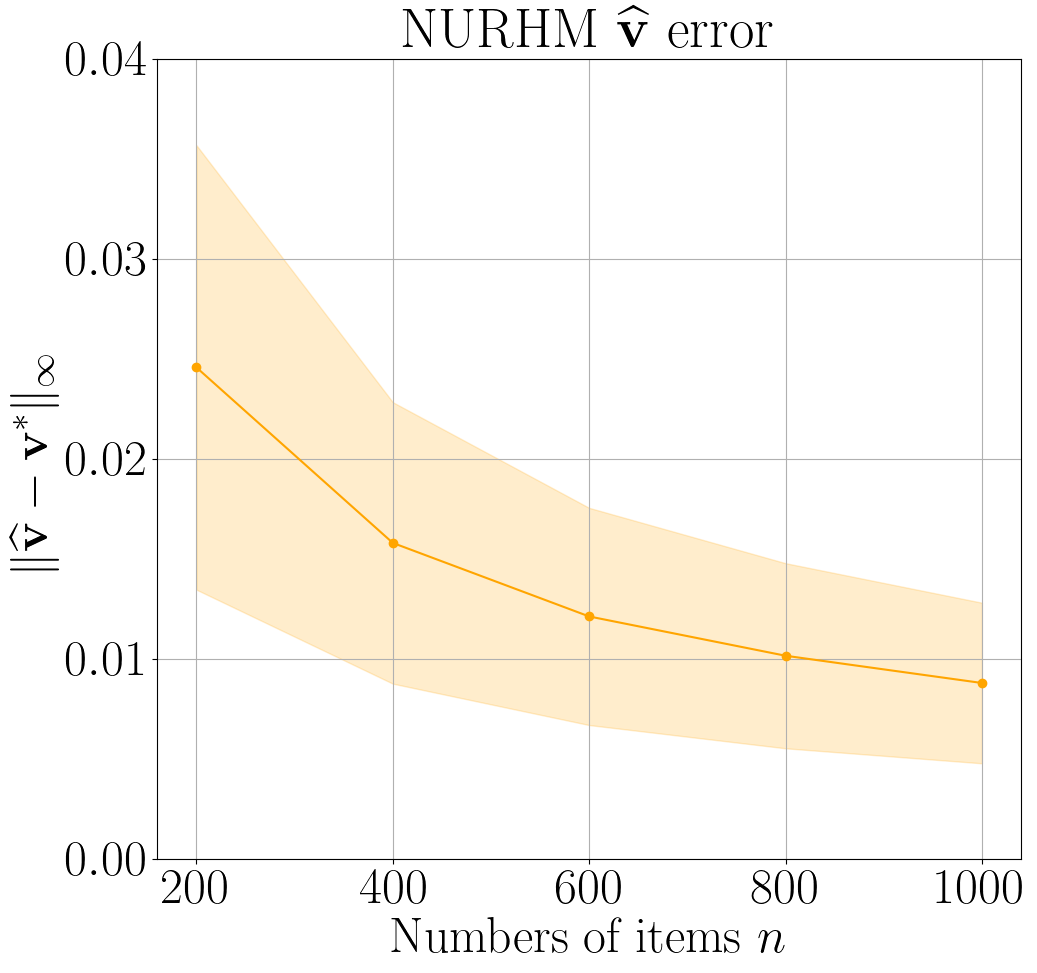

In [ ]:
basicfun.plot('NURHM',save_path)

##### HSBM

In [ ]:
N = lambda n: int(0.07*n**2)
m_lower = 5
m_upper = 6
simulation(n, N, v, m_lower, m_upper, repeat_time = repeat_time,name = 'HSBM')

----------
complete get edges: Num_Edges=2800, Num_Nodes = 200,m_lower = 5,m_upper = 5
[[83, 79, 88, 125, 117], [27, 90, 100, 157, 108], [101, 98, 93, 106, 144], [132, 190, 67, 96, 121], [161, 171, 69, 160, 141], [159, 80, 174, 128, 75], [91, 79, 143, 73, 96], [182, 183, 148, 161, 130], [89, 192, 128, 180, 98], [77, 71, 90, 97, 160], [78, 131, 117, 142, 80], [86, 153, 99, 173, 162], [24, 64, 63, 54, 29], [137, 110, 81, 181, 190], [197, 107, 189, 133, 191], [115, 148, 153, 149, 194], [170, 176, 165, 198, 189], [115, 156, 79, 166, 180], [44, 0, 43, 50, 25], [183, 128, 96, 164, 125], [109, 164, 72, 100, 186], [47, 56, 19, 18, 49], [50, 17, 21, 48, 2], [43, 29, 27, 47, 23], [142, 156, 115, 163, 85], [119, 72, 166, 120, 186], [122, 163, 66, 93, 169], [159, 152, 99, 143, 95], [48, 95, 111, 84, 60], [11, 12, 13, 59, 9], [180, 198, 90, 137, 178], [167, 197, 126, 96, 119], [128, 163, 102, 192, 124], [123, 177, 149, 116, 117], [82, 177, 170, 168, 162], [85, 191, 99, 132, 184], [136, 180, 173, 14

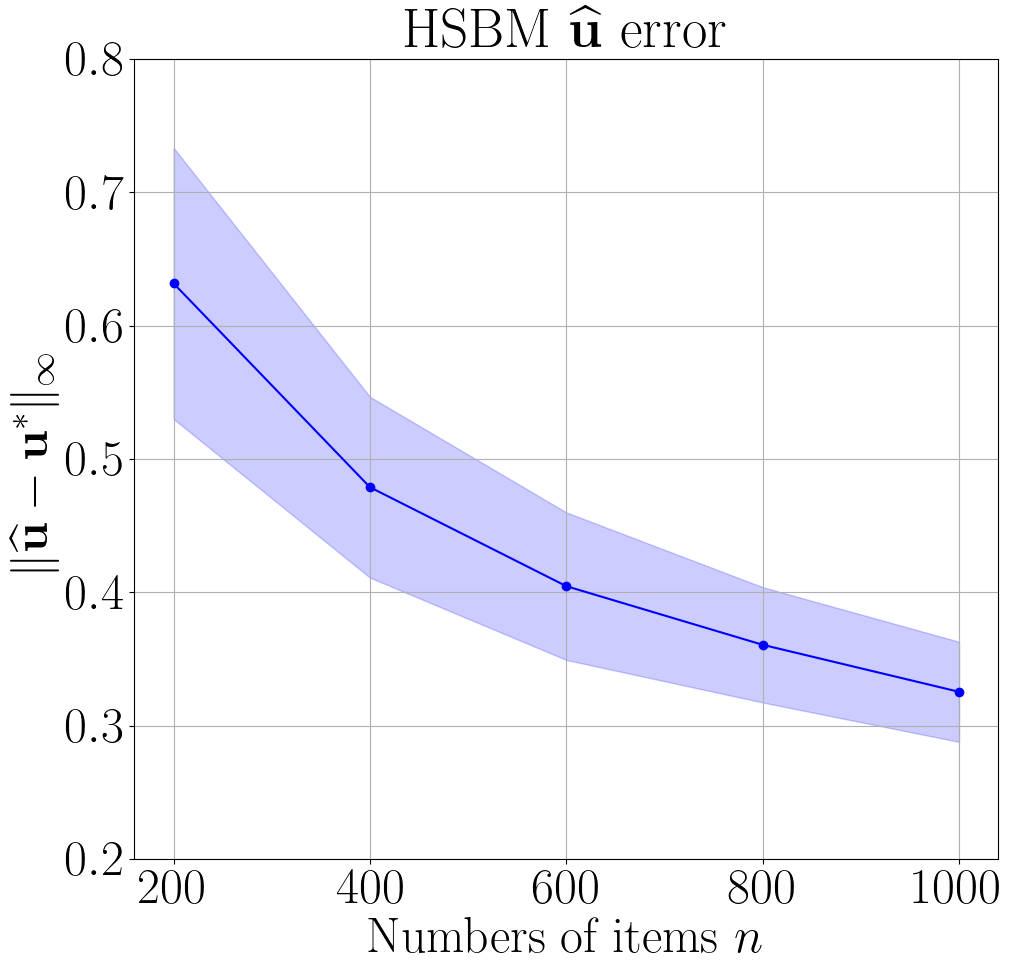

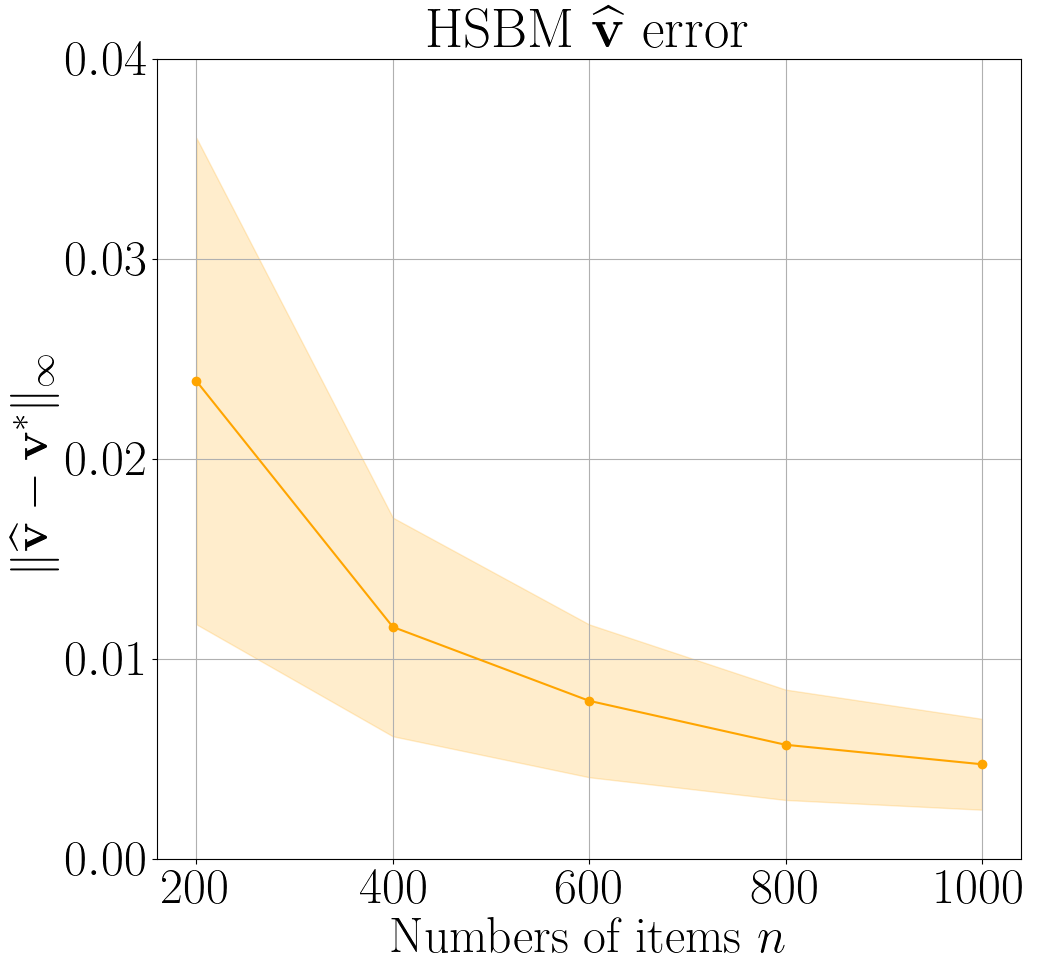

In [ ]:
basicfun.plot('HSBM',save_path)

### Convergence rate of alternating maximization algorithm

In [ ]:
n = 200
N = lambda n: int(n*(n-1)/2)
v = [1,-0.5,0]
d = len(v)
m_lower = 2
m_upper = 3
H = generator.MultipleComparison(n,N,v,m_lower=m_lower,m_upper=m_upper)

complete get edges: Num_Edges=19900, Num_Nodes = 200,m_lower = 2,m_upper = 3


In [ ]:
U = [np.zeros(n)]
V = [np.zeros(d)]
UU,VV = [],[]
for i in range(3):
    U = MM_pair(H.T,H.X,V[-1],n,utr=U[-1])
    V = Newton_pair(H.T,H.X,U[-1],d,vtr=V[-1],E=1e-8)
    U_error = [np.linalg.norm(u-U[-1]) for u in U[:-1]]
    U_error_ratio = [U_error[i+1]/U_error[i] for i in range(len(U_error)-1)]
    V_error = [np.linalg.norm(v-V[-1]) for v in V[:-1]]
    V_error_ratio = [V_error[i+1]/V_error[i] for i in range(len(V_error)-1)]
    #UU.append(U_error_ratio)
    #VV.append(V_error_ratio)
    UU.append(U_error)
    VV.append(V_error)


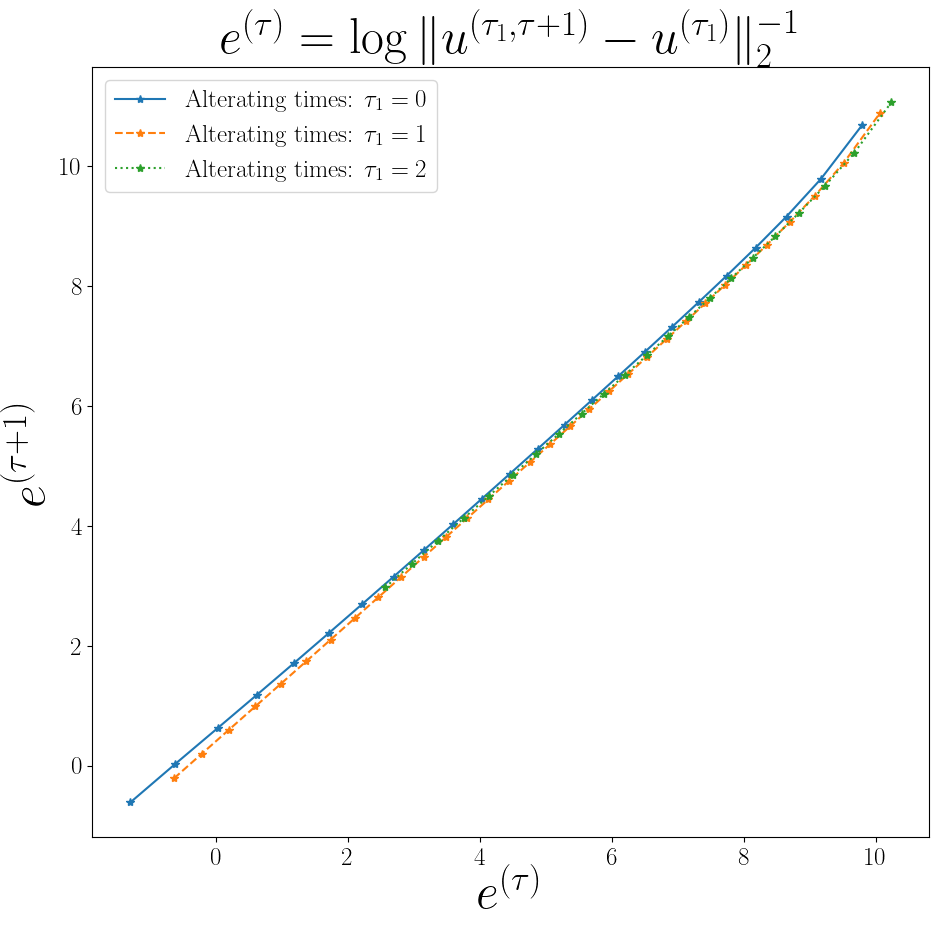

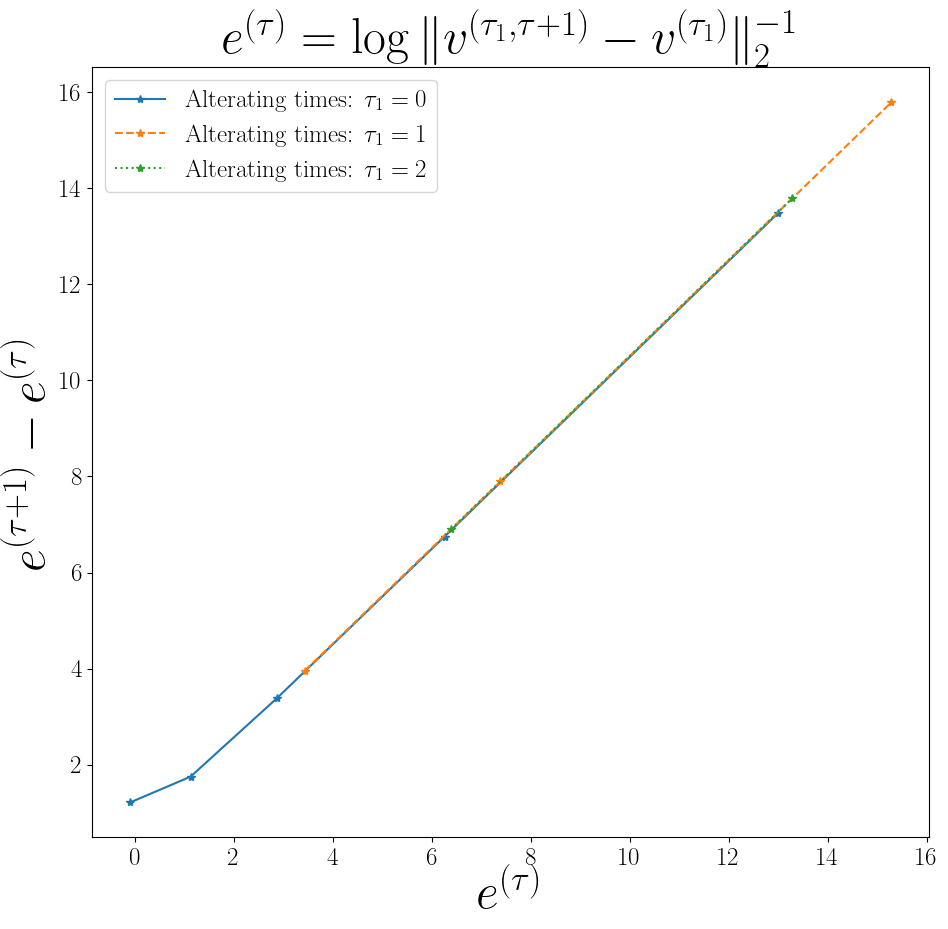

In [ ]:
T = ['-*','--*',':*',':']
rc('text', usetex=True)
rc('font', family='serif')
sz = 36
title_u = r'$e^{(\tau)} = \log\|u^{(\tau_1,\tau+1)}-u^{(\tau_1)}\|_2^{-1}$'
title_v = r'$e^{(\tau)} = \log\|v^{(\tau_1,\tau+1)}-v^{(\tau_1)}\|_2^{-1}$'
ylabel_u = r'$e^{(\tau+1)}$'
ylabel_v = r'$e^{(\tau+1)}-e^{(\tau)}$'
xlabel = r'$e^{(\tau)}$'

fig, ax = plt.subplots(figsize=(10.8, 10))
plt.xticks(size=sz/2)
plt.yticks(size=sz/2)
plt.title(title_u,size =sz)

for i,U in enumerate(UU):
    ax.plot(-np.log(U[:-1]),-np.log(U[1:]),T[i],label = fr"Alterating times: $\tau_1 = {i}$",)
    ax.set_xlabel(xlabel,size = sz)
    ax.set_ylabel(ylabel_u,size = sz)
plt.legend(fontsize=sz/2)
plt.savefig(save_path+'convergence_rate_u.pdf')

fig, ax = plt.subplots(figsize=(10.8, 10))
plt.xticks(size=sz/2)
plt.yticks(size=sz/2)
plt.title(title_v,size =sz)
for i,V in enumerate(VV):
    ax.plot(-np.log(V[:-1]),-np.log(V[1:])+np.log(V[:-1]),T[i],label = fr"Alterating times: $\tau_1 = {i}$",)
    ax.set_xlabel(xlabel,size = sz)
    ax.set_ylabel(ylabel_v,size = sz)

x = np.linspace(0,5,500)
plt.legend(fontsize=sz/2)
plt.savefig(save_path+'convergence_rate_v.pdf')


plt.show()

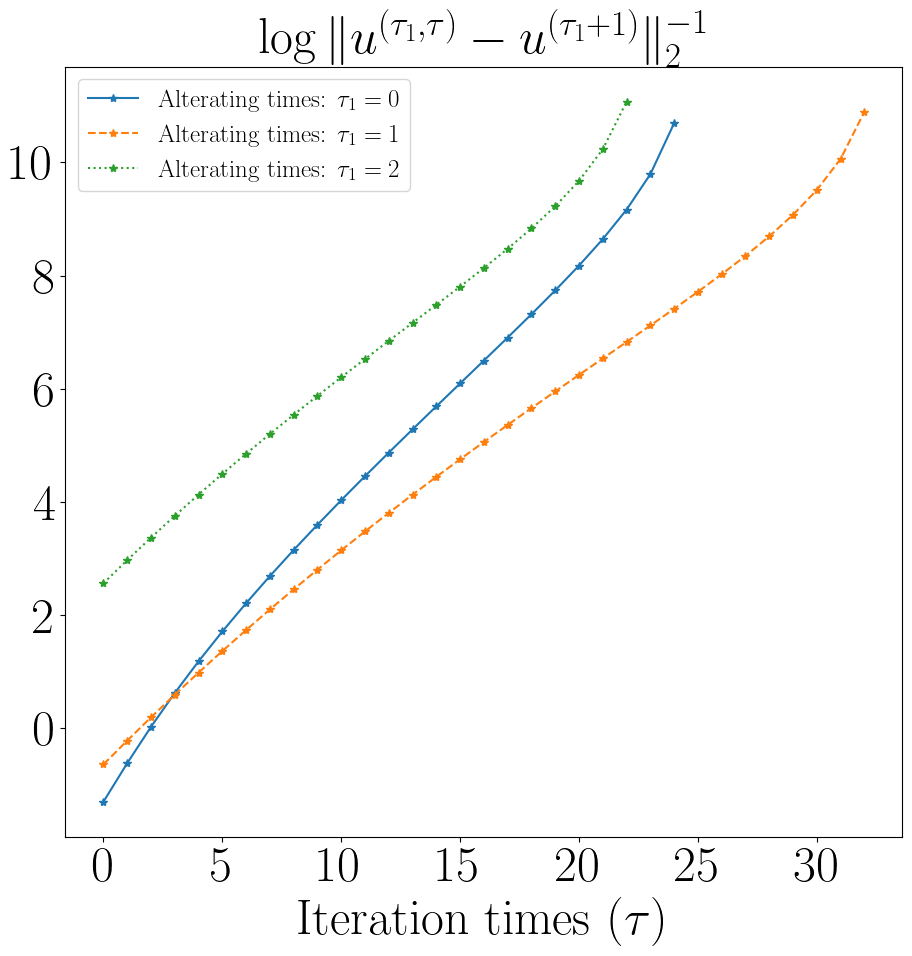

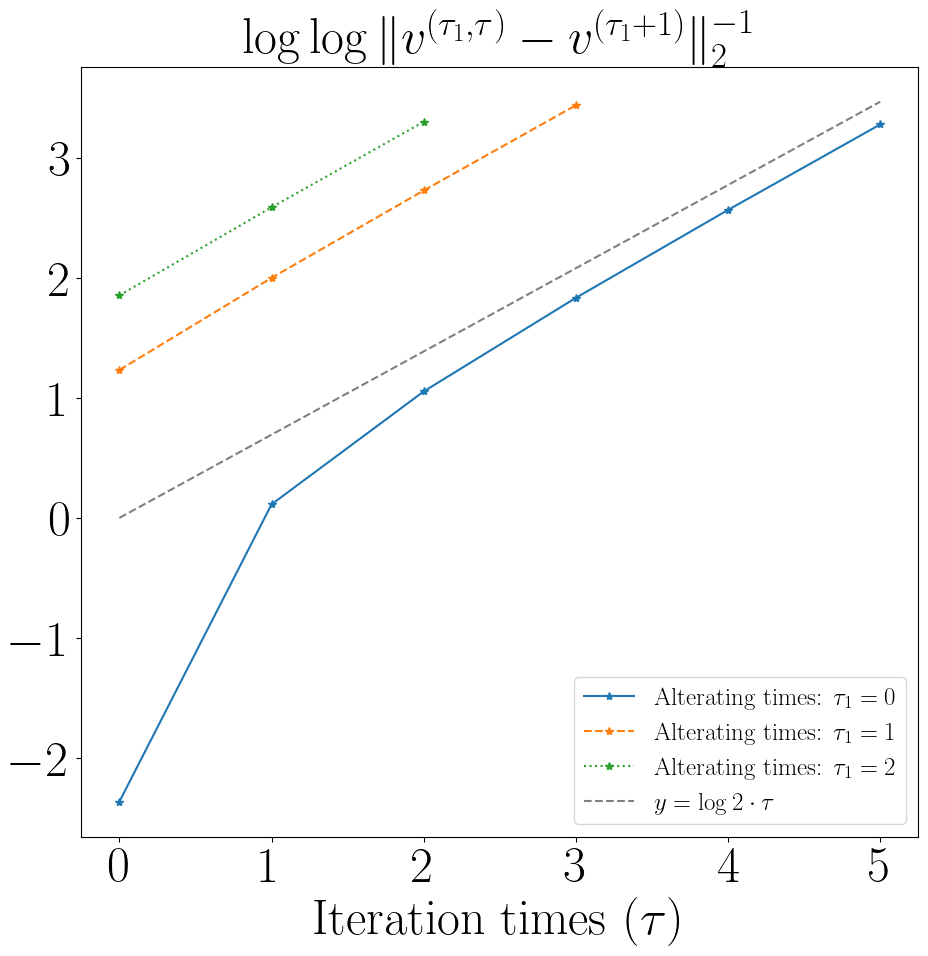

In [ ]:
title = ""
#Tu_ = r'$\frac{\|u^{(\tau_1,\tau_2+1)}-u^{(\tau_1+1)}\|_2}{\|u^{(\tau_1,\tau_2)}-u^{(\tau_1+1)}\|_2}$'
Tu_ = r'$\log\|u^{(\tau_1,\tau)}-u^{(\tau_1+1)}\|^{-1}_2$'
#Tv_ = r'$\frac{\|v^{(\tau_1,\tau_2+1)}-v^{(\tau_1+1)}\|_2}{\|v^{(\tau_1,\tau_2)}-v^{(\tau_1+1)}\|_2}$'
Tv_ = r'$\log\log\|v^{(\tau_1,\tau)}-v^{(\tau_1+1)}\|^{-1}_2$'
ylabel = 'Error ratio'
xlabel = r'Iteration times ($\tau$)'

fig, ax = plt.subplots(figsize=(10.8, 10))
plt.xticks(size=sz)
plt.yticks(size=sz)
plt.title(title+Tu_,size =sz)
for i,U in enumerate(UU):
    ax.plot(range(len(U)),-np.log(U),T[i],label = fr"Alterating times: $\tau_1 = {i}$",)
    ax.set_xlabel(xlabel,size = sz)
plt.legend(fontsize=sz/2)
plt.savefig(save_path+'convergence_rate_u(alternative).pdf')

fig, ax = plt.subplots(figsize=(10.8, 10))
plt.title(title+Tv_,size =sz)
plt.xticks(size=sz)
plt.yticks(size=sz)
for i,V in enumerate(VV):
    ax.plot(range(len(V)),np.log(abs(np.log(V))),T[i],label = fr"Alterating times: $\tau_1 = {i}$",)
    ax.set_xlabel(xlabel,size = sz)

x = np.linspace(0,5,500)
ax.plot(x,np.log(2)*x,'--',label = r"$y=\log2\cdot \tau$ ",color = 'grey')
plt.legend(fontsize=sz/2)
plt.savefig(save_path+'convergence_rate_v(alternative).pdf')


plt.show()

### Does covariate fully capture the score?（simulation）

Set $\rm num\in\{10,15,20\}$

In [2]:
num = 15 #{10,15,20}

n = 2000
d = 4
v = np.array([(i+1)/d for i in range(d)])
X = np.random.normal(0,1,(n,d))
p = algorithm.s(X@v)
save_data_path = os.getcwd() + '\\' + 'data' + '\\' + 'synthesis'+ '\\'
file_name = 'inference test'
file_name_1 = 'DS'
file_name_2 = 'Dp-v'

In [3]:
repeat_times = 100000
tasks = [delayed(algorithm.test_statistics)(X,d,num,v) for _ in range(repeat_times)]
results = Parallel(n_jobs=10)(tasks)
results = np.array(results)
with open(save_data_path+file_name+f'({num},{n}).txt','a') as file:
    for r in results:
        for rr in r:
            file.write(f'{str(rr)},')
        file.write('\n')

Distribution of statistic

In [4]:
statistics,p_value = [],[]
with open(save_data_path+file_name+f'({num},{n}).txt','r') as file:
    for line in file:
        temp = line.split(',')
        statistics.append(float(temp[0]))
        p_value.append(float(temp[1]))
  
np.mean(statistics), np.std(statistics)**2/2

(14.018507627599778, 14.035354402144408)

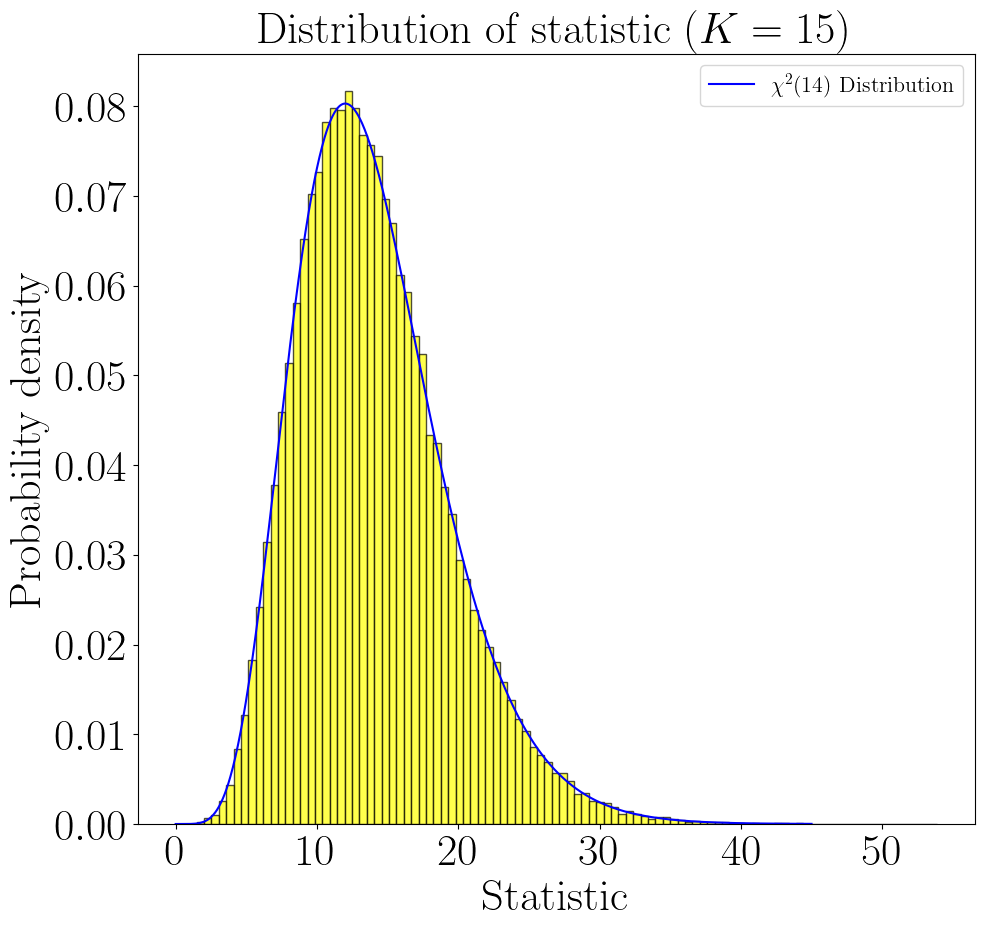

In [5]:
plt.figure(figsize=(10.8, 10))
x = np.linspace(0,3*num, 1000)
pdf = chi2.pdf(x, num-1)
plt.hist(statistics, bins=100, alpha=0.7, color='yellow', edgecolor='black',density = True)
plt.plot(x, pdf, label=fr'$\chi^2({num-1})$ Distribution', color='blue')
plt.title(fr"Distribution of statistic ($K={num}$)",size =sz)
plt.xlabel('Statistic',size =sz)
plt.ylabel('Probability density',size =sz)
plt.xticks(size=sz)
plt.yticks(size=sz)
plt.legend(fontsize=sz/2)
plt.savefig(save_path+file_name_1+f'({num}).pdf')

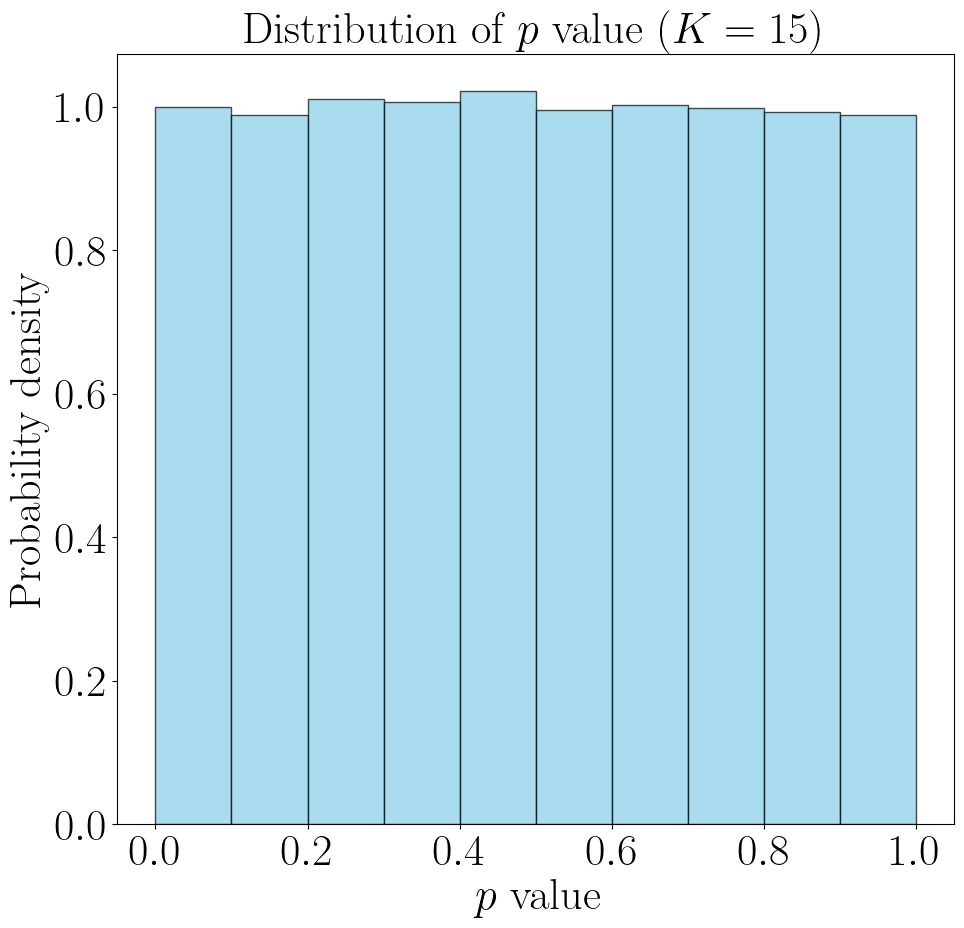

In [6]:
plt.figure(figsize=(10.8, 10))
plt.hist(p_value, bins=10, alpha=0.7, color='skyblue', edgecolor='black',density = True)
plt.title(fr"Distribution of $p$ value ($K={num}$)",size =sz)
plt.xlabel(r'$p$ value',size=sz)
plt.ylabel('Probability density',size=sz)
plt.xticks(size=sz)
plt.yticks(size=sz)
plt.savefig(save_path+file_name_2+f'({num}).pdf')